# Libraries
Load the Python libraries needed for cleaning, analysis, and visualization.

In [34]:
# Load libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats


In [2]:
# Set the data path and display options
file_path = '/Users/yezawmyint/My Project/E-commerce (decodelab)/Dataset for Data Analytics.csv'
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 20)

In [3]:
# Convert PascalCase names to snake_case
import re

def pascal_to_snake(cols):
    result=[]
    for value in cols:
        value = re.sub(r'([A-Z]+)([A-Z][a-z])', r'\1_\2', value)
        value = re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', value)
        value = value.lower()
        result.append(value)
    return result

In [4]:
# Load the dataset
df = pd.read_csv(file_path)

In [5]:
# Preview the dataset
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


# Data Cleaning
Prepare the dataset by standardizing names, formats, and values.
## Change Column name
Use consistent snake_case names for all columns.

In [6]:
# Rename columns to snake_case
df.columns = pascal_to_snake(df.columns)

In [7]:
# Check the new column names
df.columns

Index(['order_id', 'date', 'customer_id', 'product', 'quantity', 'unit_price',
       'shipping_address', 'payment_method', 'order_status', 'tracking_number',
       'items_in_cart', 'coupon_code', 'referral_source', 'total_price'],
      dtype='str')

In [8]:
# Check the number of rows and columns
df.shape

(1200, 14)

In [9]:
# Inspect column types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1200 non-null   str    
 1   date              1200 non-null   str    
 2   customer_id       1200 non-null   str    
 3   product           1200 non-null   str    
 4   quantity          1200 non-null   int64  
 5   unit_price        1200 non-null   float64
 6   shipping_address  1200 non-null   str    
 7   payment_method    1200 non-null   str    
 8   order_status      1200 non-null   str    
 9   tracking_number   1200 non-null   str    
 10  items_in_cart     1200 non-null   int64  
 11  coupon_code       891 non-null    str    
 12  referral_source   1200 non-null   str    
 13  total_price       1200 non-null   float64
dtypes: float64(2), int64(2), str(10)
memory usage: 226.8 KB


## Check duplicate
Check for repeated rows and repeated order IDs.

In [10]:
# Count duplicate rows
df.duplicated().sum()

np.int64(0)

In [11]:
# Count duplicate order IDs
df['order_id'].duplicated().sum()

np.int64(0)

## Droping unneceassy
Remove columns that are not needed for the analysis.

In [12]:
# Remove unnecessary columns
df.drop(columns='shipping_address', inplace=True)
# df.drop(columns='total_price', inplace=True)

## Standardizing format
Make dates, numbers, and missing values consistent.

In [13]:
# Convert the date column to datetime
df["date"] = pd.to_datetime(df["date"])

In [14]:
# Round decimal columns to two places
float_cols=df.select_dtypes(include=[float]).columns
df[float_cols]= df[float_cols].round(2)

In [15]:
# Fill missing values with a label
df.fillna('N/A', inplace= True)

,order_id,date,customer_id,product,quantity,unit_price,payment_method,order_status,tracking_number,items_in_cart,coupon_code,referral_source,total_price
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,Online,Cancelled,TRK69207593,5,N/A,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [16]:
# List the unique products
set(df['product'])

{'Chair', 'Desk', 'Laptop', 'Monitor', 'Phone', 'Printer', 'Tablet'}

## Data Validation
Check that calculated values follow the expected business rules.

In [17]:
# Check that quantity times unit price equals total price
all_valid = True

for _, row in df.iterrows():
    is_valid = np.isclose(
        row["quantity"] * row["unit_price"],
        row["total_price"]
    )

    if not is_valid:
        all_valid = False
        print(f"Invalid row found: {row.name}")

print(all_valid)

True


# Exploratory Data Analysis
Explore patterns, totals, distributions, and relationships in the data.

## Grouping Data
Separate orders by status and summarize product performance.

In [18]:
# Create dataframes for shipped and returned orders
df_shipped = df[df['order_status'].isin(['Shipped'])]
df_returned = df[df['order_status'].isin(['Returned'])]

In [19]:
# Summarize shipped products and rank them by quantity
summary = df_shipped.pivot_table(
    values=['quantity', 'total_price', 'items_in_cart'],
    index='product',
    aggfunc='sum',
    margins=True
).round(2)

total = summary.loc[['All']]
summary = summary.drop(index='All').sort_values('quantity', ascending=False)
summary.insert(0, 'rank', range(1, len(summary) + 1))

total.insert(0, 'rank', pd.NA)
summary = pd.concat([summary, total])
summary = summary[['rank', 'quantity', 'total_price', 'items_in_cart']]

print(summary)

         rank  quantity  total_price  items_in_cart
product                                            
Printer     1       124     44397.41            225
Laptop      2       102     40237.23            176
Tablet      3       102     34828.15            214
Chair       4        99     40350.44            178
Desk        5        97     33424.89            187
Monitor     6        93     30924.82            176
Phone       7        63     21996.64            132
All      <NA>       680    246159.58           1288


In [20]:
# Summarize returned products
df_returned.pivot_table(
    values=['quantity', 'unit_price', 'items_in_cart', 'total_price'],
    index='product',
    aggfunc='sum',
    margins=True
).round(2)

,items_in_cart,quantity,total_price,unit_price
product,,,,
Chair,145,71,26638.16,10800.22
Desk,180,86,28831.49,10371.03
Laptop,200,114,39654.30,13537.38
Monitor,195,97,40524.60,13652.15
Phone,154,77,29164.20,11572.54
Printer,206,114,35939.09,12496.64
Tablet,247,123,42525.86,14792.62
All,1327,682,243277.70,87222.58


## Visualization
Visualize product quantities to compare sales performance.

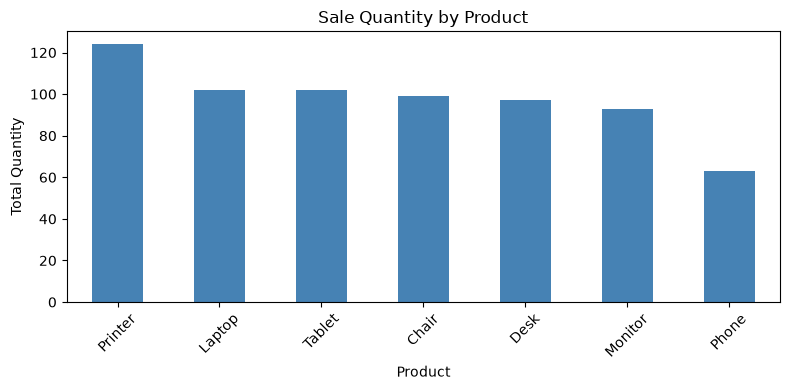

In [21]:
# Plot shipped quantity by product
quantity_by_product = df_shipped.groupby("product")["quantity"].sum().sort_values(ascending=False)
quantity_by_product.plot(
    kind="bar",
    figsize=(8, 4),
    title="Sale Quantity by Product",
    color="steelblue" 
)
plt.xlabel("Product")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Histogram

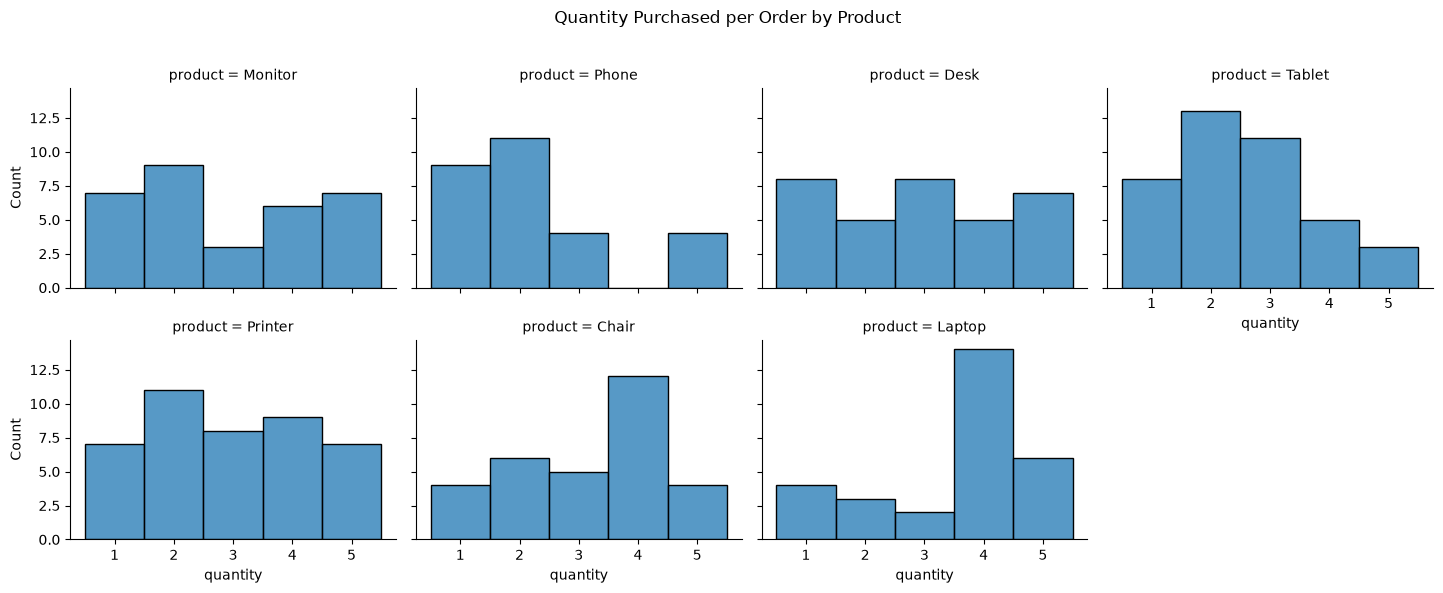

In [22]:
sns.displot(
    data=df_shipped,
    x="quantity",
    col="product",
    col_wrap=4,
    discrete=True,
    height=3,
    aspect=1.2,
    facet_kws={
        "sharex": True,
        "sharey": True
    }
)

plt.subplots_adjust(top=0.85)
plt.suptitle("Quantity Purchased per Order by Product")
plt.show()

## Boxplot
Use a boxplot to identify unusual returned quantities.

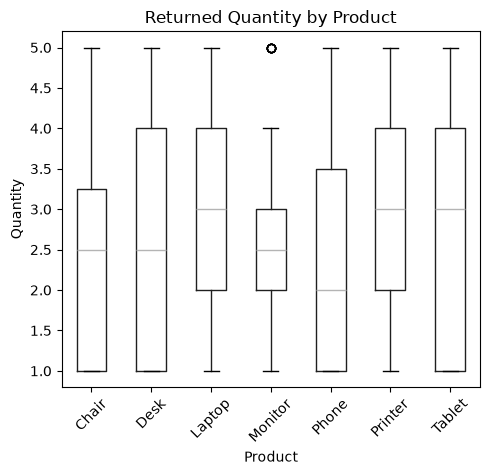

In [23]:
# Plot the distribution of returned quantities
quantity_by_returned = df_returned.groupby("product")["quantity"].sum().sort_values(ascending=False)
df_returned.boxplot(
    column="quantity",
    by="product",
    figsize=(5, 5),
    grid=False
)
plt.title("Returned Quantity by Product")
plt.suptitle("")
plt.xlabel("Product")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Pie Chart

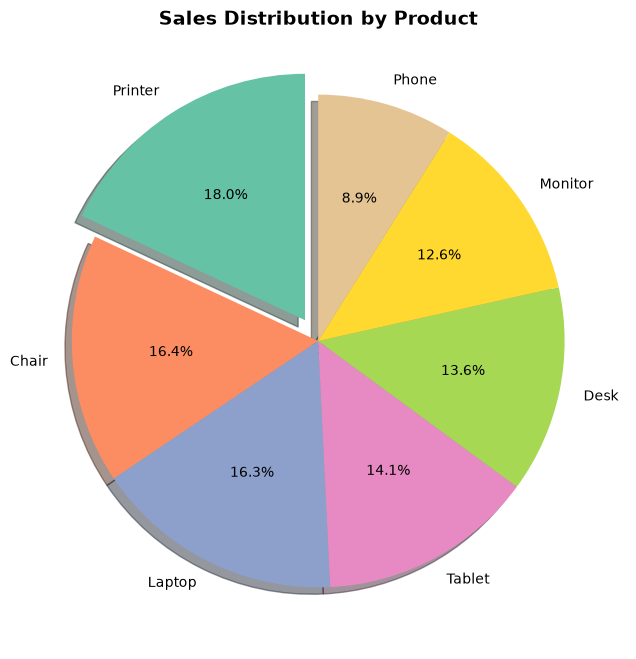

In [27]:
# Pie chart: sales distribution by product
sales_by_product = (
    df_shipped.groupby("product")["total_price"]
    .sum()
    .sort_values(ascending=False)
)

categories = sales_by_product.index
sizes = sales_by_product.values
colors = sns.color_palette("Set2", len(categories))
explode = [0.1] + [0] * (len(categories) - 1)

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    sizes,
    explode=explode,
    labels=categories,
    colors=colors,
    autopct="%1.1f%%",
    shadow=True,
    startangle=90
)
ax.set_title("Sales Distribution by Product", fontsize=14, fontweight="bold")
plt.show()

# Statistics
Compare the average, middle, variation, and total sales values.

In [24]:
# Calculate sales statistics by product
df_shipped.groupby("product")["total_price"].agg(
    ["mean", "median", "std", "sum"]
).round(2)

,mean,median,std,sum
product,,,,
Chair,1301.63,1291.70,840.65,40350.44
Desk,1012.88,1069.34,724.74,33424.89
Laptop,1387.49,1055.72,973.42,40237.23
Monitor,966.40,708.12,838.21,30924.82
Phone,785.59,598.39,460.97,21996.64
Printer,1057.08,745.89,881.80,44397.41
Tablet,870.70,681.96,609.11,34828.15


## Outliers
Identify customers whose total spending falls outside the typical range using the IQR method.

In [41]:
# Calculate each customer's total spending
df_total_price = df_shipped.groupby('customer_id')['total_price'].sum()
# Calculate the interquartile range and outlier boundaries
iqr_total_price = stats.iqr(df_total_price)
upper_limit = np.quantile(df_total_price, 0.75) + 1.5 * iqr_total_price
lower_limit = np.quantile(df_total_price, 0.25) - 1.5 * iqr_total_price

# Store customers whose spending is outside the IQR boundaries
outliers = []
for customer, total_price in df_total_price.items():
    if total_price < lower_limit or total_price > upper_limit:
        outliers.append(customer)
print(outliers)

['C16775', 'C25276']


In [42]:
# Display the original rows for the identified outlier customers
df[df['customer_id'].isin(outliers)]

,order_id,date,customer_id,product,quantity,unit_price,payment_method,order_status,tracking_number,items_in_cart,coupon_code,referral_source,total_price
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75
463,ORD200463,2023-05-26,C25276,Laptop,5,662.78,Debit Card,Shipped,TRK14011732,9,SAVE10,Instagram,3313.90


## Correlation check
Measure how the numeric columns move in relation to each other.

<Axes: >

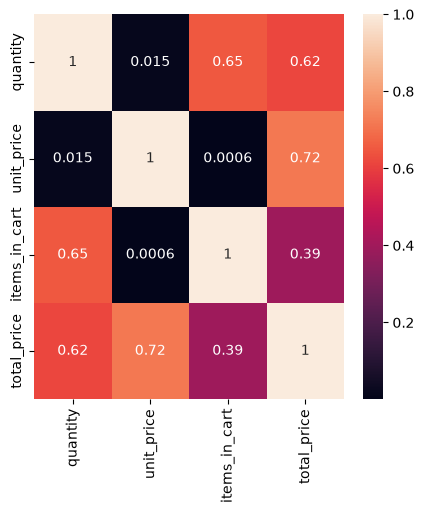

In [25]:
# Calculate and display numeric correlations
corr_df= df.loc[:, ['quantity', 'unit_price', 'items_in_cart', 'total_price']].corr()
plt.rcParams['figure.figsize']=(5,5)
sns.heatmap(corr_df, annot=True)